# VeReMi Sybil Dataset — Exploratory Data Analysis

This notebook performs a comprehensive EDA on the local VeReMi dataset and
prepares a model-ready dataset saved to `data/prepared_data/`.

**Dataset structure:**
- 4 attack families × 2 time-groups (`0709`, `1416`)
- Each subfolder contains per-vehicle trace JSON files and a ground-truth file
- Filenames encode: `traceJSON-{nodeId}-{pseudoId}-A{attackType}-{startTime}-{simNum}.json`
- `A0` = benign vehicle, `A16` = GridSybil, `A17` = DataReplaySybil, `A18` = DoSRandom, `A19` = DoSDisruptive

In [1]:
import json
import os
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

BASE = Path("data/VeReMi-Dataset")
PREPARED = Path("data/prepared_data")
PREPARED.mkdir(parents=True, exist_ok=True)

# Attack type code → label mapping
ATTACK_MAP = {
    0:  "Benign",
    16: "GridSybil",
    17: "DataReplaySybil",
    18: "DoSRandomSybil",
    19: "DoSDisruptiveSybil",
}

print(f"Base path exists: {BASE.exists()}")
print(f"Scenario families: {sorted([d.name for d in BASE.iterdir() if d.is_dir()])}")

Base path exists: True
Scenario families: ['DataReplaySybil_0709', 'DataReplaySybil_1416', 'DoSDisruptiveSybil_0709', 'DoSDisruptiveSybil_1416', 'DoSRandomSybil_0709', 'DoSRandomSybil_1416', 'GridSybil_0709', 'GridSybil_1416']


### Understanding ATTACK_MAP and File Naming

**ATTACK_MAP Dictionary:**
The `ATTACK_MAP` below maps attack type codes extracted from trace **filenames** to human-readable labels:
- `0` → **Benign**: Normal vehicles following traffic rules (A0 in filename)
- `16` → **GridSybil**: Positions scatter in a grid pattern far outside road network (A16)
- `17` → **DataReplaySybil**: Replays old GPS data from benign vehicles (A17)
- `18` → **DoSRandomSybil**: Sends BSMs at random intervals (0.5s, 2× normal rate) (A18)
- `19` → **DoSDisruptiveSybil**: DoS variant with disruptive positioning (0.5s intervals + off-road) (A19)

**Filename Encoding:**
Each trace file follows pattern: `traceJSON-{nodeId}-{pseudoId}-A{attackType}-{startTime}-{simNum}.json`

Example: `traceJSON-10011-10009-A17-28468-7.json` 
- nodeId=10011, pseudoId=10009, attackType=17 (DataReplaySybil), startTime=28468

## 1. Dataset Inventory

Scan all scenario folders: count trace files, ground-truth files, benign vs attacker vehicles.

In [2]:
def parse_trace_filename(name):
    """Extract node_id, pseudo_id, attack_type, start_time from trace filename."""
    # traceJSON-{nodeId}-{pseudoId}-A{attackType}-{startTime}-{simNum}.json
    m = re.match(r'traceJSON-(\d+)-(\d+)-A(\d+)-(\d+)-(\d+)\.json', name)
    if not m:
        return None
    return {
        'node_id': int(m.group(1)),
        'pseudo_id': int(m.group(2)),
        'attack_code': int(m.group(3)),
        'start_time': int(m.group(4)),
        'sim_num': int(m.group(5)),
    }

inventory = []
for family_dir in sorted(BASE.iterdir()):
    if not family_dir.is_dir():
        continue
    family_name = family_dir.name
    # Parse family and group from folder name e.g. DataReplaySybil_0709
    parts = family_name.rsplit('_', 1)
    family, group = parts[0], parts[1]
    
    for sub_dir in sorted(family_dir.iterdir()):
        if not sub_dir.is_dir():
            continue
        gt_files = list(sub_dir.glob('traceGroundTruth*.json'))
        trace_files = list(sub_dir.glob('traceJSON-*.json'))
        
        benign_count = sum(1 for f in trace_files if parse_trace_filename(f.name) and parse_trace_filename(f.name)['attack_code'] == 0)
        attacker_count = len(trace_files) - benign_count
        
        inventory.append({
            'family': family,
            'group': group,
            'subfolder': sub_dir.name,
            'gt_files': len(gt_files),
            'total_traces': len(trace_files),
            'benign_vehicles': benign_count,
            'attacker_vehicles': attacker_count,
            'path': str(sub_dir),
        })

df_inv = pd.DataFrame(inventory)
print(f"Total scenario subfolders: {len(df_inv)}")
print(f"Total trace files: {df_inv['total_traces'].sum():,}")
print(f"Total benign vehicles: {df_inv['benign_vehicles'].sum():,}")
print(f"Total attacker vehicles: {df_inv['attacker_vehicles'].sum():,}")
print()
df_inv.drop(columns='path')

Total scenario subfolders: 20
Total trace files: 23,032
Total benign vehicles: 16,122
Total attacker vehicles: 6,910



,family,group,subfolder,gt_files,total_traces,benign_vehicles,attacker_vehicles
0,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46,1,1847,1293,554
1,DataReplaySybil,0709,VeReMi_28800_32400_2022-9-13_21:7:46,1,2221,1554,667
2,DataReplaySybil,1416,VeReMi_50400_54000_2022-9-11_19:14:14,1,1004,703,301
3,DataReplaySybil,1416,VeReMi_54000_57600_2022-9-11_19:14:14,1,685,479,206
4,DataReplaySybil,1416,VeReMi_57600_61200_2022-9-11_19:14:14,0,2,2,0
5,DoSDisruptiveSybil,0709,VeReMi_25200_28800_2022-9-13_21:8:24,1,1847,1293,554
6,DoSDisruptiveSybil,0709,VeReMi_28800_32400_2022-9-13_21:8:24,1,2221,1554,667
7,DoSDisruptiveSybil,1416,VeReMi_50400_54000_2022-9-11_19:14:41,1,1004,703,301
8,DoSDisruptiveSybil,1416,VeReMi_54000_57600_2022-9-11_19:14:41,1,685,479,206
9,DoSDisruptiveSybil,1416,VeReMi_57600_61200_2022-9-11_19:14:41,0,2,2,0


### Folder Structure and Data Organization

The dataset at `data/VeReMi-Dataset/` is organized as **4 attack families × 2 time groups**:

**Time Groups (Daily Scenarios):**
- `0709`: Morning scenarios (7:00 AM - 9:00 AM)
- `1416`: Afternoon scenarios (2:00 PM - 4:00 PM)

**Attack Families (8 scenario folders total):**
1. `DataReplaySybil_0709` & `DataReplaySybil_1416` — Replay attacks
2. `DoSRandomSybil_0709` & `DoSRandomSybil_1416` — Random DoS attacks
3. `DoSDisruptiveSybil_0709` & `DoSDisruptiveSybil_1416` — Disruptive DoS attacks
4. `GridSybil_0709` & `GridSybil_1416` — Grid-pattern attacks

**Sub-window Structure:**
Each family folder contains 2-3 sub-folders for different time windows (e.g., `VeReMi_25200_28800_...`):
- Start/end times indicate simulation duration
- Each contains ~1,000-2,200 trace files and one ground truth file
- Some folders (like `_57600_61200` in 1416 groups) are nearly empty (~2 traces only)

## 2. Load All Ground Truth Messages

Parse ground truth files to get the sender-side view of all BSMs. These contain
the actual sent values (pos, spd, acl, hed) per message.

In [3]:
def load_ground_truth(gt_path, family, group, subfolder):
    """Load all lines from a ground truth JSON file."""
    rows = []
    with open(gt_path) as f:
        for line in f:
            obj = json.loads(line)
            rows.append({
                'sendTime': obj['sendTime'],
                'sender': obj['sender'],
                'senderPseudo': obj['senderPseudo'],
                'messageID': obj['messageID'],
                'pos_x': obj['pos'][0],
                'pos_y': obj['pos'][1],
                'spd_x': obj['spd'][0],
                'spd_y': obj['spd'][1],
                'acl_x': obj['acl'][0],
                'acl_y': obj['acl'][1],
                'hed_x': obj['hed'][0],
                'hed_y': obj['hed'][1],
                'type': obj['type'],
                'family': family,
                'group': group,
                'subfolder': subfolder,
            })
    return rows

all_gt_rows = []
for _, row in tqdm(df_inv.iterrows(), total=len(df_inv), desc="Loading GT"):
    sub_path = Path(row['path'])
    for gt_file in sub_path.glob('traceGroundTruth*.json'):
        all_gt_rows.extend(load_ground_truth(gt_file, row['family'], row['group'], row['subfolder']))

df_gt = pd.DataFrame(all_gt_rows)
print(f"Total ground truth messages: {len(df_gt):,}")
print(f"Columns: {list(df_gt.columns)}")
print(f"Memory: {df_gt.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_gt.head()

Loading GT: 100%|██████████| 20/20 [00:16<00:00,  1.24it/s]


Total ground truth messages: 3,240,283
Columns: ['sendTime', 'sender', 'senderPseudo', 'messageID', 'pos_x', 'pos_y', 'spd_x', 'spd_y', 'acl_x', 'acl_y', 'hed_x', 'hed_y', 'type', 'family', 'group', 'subfolder']
Memory: 988.1 MB


,sendTime,sender,senderPseudo,messageID,pos_x,pos_y,spd_x,spd_y,acl_x,acl_y,hed_x,hed_y,type,family,group,subfolder
0,25202.602763,9,1092,4184,265.633775,45.992725,-0.050543,0.489116,-0.249488,2.414413,-0.102790,0.994703,4,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46
1,25203.602763,9,1092,4194,265.693767,47.701780,-0.269606,2.609096,-0.206703,2.000590,-0.101639,0.994821,4,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46
2,25204.602763,9,1092,4204,265.442373,51.317633,-0.461526,4.466847,-0.148893,1.441121,-0.101639,0.994821,4,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46
3,25205.602763,9,1092,4214,264.659931,56.898323,-0.722196,6.534210,-0.271944,2.460299,-0.108716,0.994073,4,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46
4,25206.602763,9,1092,4224,266.695618,64.875902,-1.183743,8.412387,-0.186514,1.325420,-0.138203,0.990404,4,DataReplaySybil,0709,VeReMi_25200_28800_2022-9-13_21:7:46


### Trace Files vs Ground Truth Files

**Trace Files** (`traceJSON-*.json`):
- **One file per vehicle** in the scenario
- **Receiver's perspective**: Contains BSMs received by that vehicle
- Line 1 (type=2): Own BSM sent by this vehicle (no sender info, first line is special)
- Lines 2+ (type=3): BSMs received from OTHER vehicles (includes sender, sendTime, messageID)
- Fields: type, pos [x,y,0], spd [vx,vy,0], acl [ax,ay,0], hed [hx,hy,0], rcvTime, etc.

**Ground Truth File** (`traceGroundTruth*.json`):
- **One file per scenario** (not per vehicle)
- **Sender's perspective**: Contains ALL BSMs sent by ALL vehicles
- Records what each vehicle actually sent (ground truth)
- All entries have type=4
- Fields: type, sender, senderPseudo, messageID, sendTime, pos, spd, acl, hed, etc.
- **Critical**: We use GT for labels by matching `GT.sender == traceFile.node_id` (100% overlap verified)

## 3. Build Per-Vehicle Attack Labels

Extract attack labels from trace filenames to label each sender in each scenario.

In [4]:
# Build a mapping: (family, group, subfolder, sender) -> attack_code
# by scanning trace filenames
vehicle_labels = []

for _, row in df_inv.iterrows():
    sub_path = Path(row['path'])
    for tf in sub_path.glob('traceJSON-*.json'):
        parsed = parse_trace_filename(tf.name)
        if parsed is None:
            continue
        vehicle_labels.append({
            'family': row['family'],
            'group': row['group'],
            'subfolder': row['subfolder'],
            'node_id': parsed['node_id'],
            'pseudo_id': parsed['pseudo_id'],
            'attack_code': parsed['attack_code'],
            'attack_label': ATTACK_MAP.get(parsed['attack_code'], f"Unknown_{parsed['attack_code']}"),
            'is_attacker': parsed['attack_code'] != 0,
        })

df_vehicles = pd.DataFrame(vehicle_labels)
print(f"Total vehicle entries: {len(df_vehicles):,}")
print(f"\nAttack code distribution:")
print(df_vehicles['attack_label'].value_counts())
print(f"\nAttacker ratio: {df_vehicles['is_attacker'].mean():.1%}")

Total vehicle entries: 23,032

Attack code distribution:
attack_label
Benign                16122
DataReplaySybil        1728
DoSDisruptiveSybil     1728
DoSRandomSybil         1728
GridSybil              1726
Name: count, dtype: int64

Attacker ratio: 30.0%


In [8]:
# Merge attack labels into ground truth using: GT.sender == filename.node_id
# (verified: 100% overlap between GT sender and filename node_id)

# Build lookup: (family, group, subfolder) -> dict of node_id -> attack info
label_lookup = {}
for _, v in df_vehicles.iterrows():
    key = (v['family'], v['group'], v['subfolder'])
    if key not in label_lookup:
        label_lookup[key] = {}
    label_lookup[key][v['node_id']] = {
        'attack_code': v['attack_code'],
        'attack_label': v['attack_label'],
        'is_attacker': v['is_attacker'],
    }

# Vectorized approach: map via a helper column
df_gt['_key'] = list(zip(df_gt['family'], df_gt['group'], df_gt['subfolder']))

def lookup_label(row_key, sender):
    info = label_lookup.get(row_key, {}).get(sender, None)
    if info is None:
        return -1, 'Unknown', False
    return info['attack_code'], info['attack_label'], info['is_attacker']

results = [lookup_label(k, s) for k, s in tqdm(zip(df_gt['_key'], df_gt['sender']), total=len(df_gt), desc="Labeling GT")]

df_gt['attack_code'] = [r[0] for r in results]
df_gt['attack_label'] = [r[1] for r in results]
df_gt['is_attacker'] = [r[2] for r in results]
df_gt.drop(columns='_key', inplace=True)

print(f"Label coverage: {(df_gt['attack_code'] != -1).mean():.1%}")
print(f"\nLabeled message distribution:")
print(df_gt['attack_label'].value_counts())

Labeling GT: 100%|██████████| 3240283/3240283 [00:00<00:00, 4167604.08it/s]


Label coverage: 100.0%

Labeled message distribution:
attack_label
Benign                1660584
GridSybil              706664
DoSDisruptiveSybil     349045
DoSRandomSybil         349045
DataReplaySybil        174945
Name: count, dtype: int64


### Attack Type Characteristics Summary

| Attack Type | Code | Distribution | Distinctive Behavior |
|---|---|---|---|
| **Benign** | A0 | ~70% of all vehicles | Follows road network, regular 1.0s message intervals |
| **DataReplaySybil** | A17 | ~5% | Replicates benign patterns but with fake identities |
| **DoSRandomSybil** | A18 | ~5% | **Sends at 0.5s intervals (2× normal)** — key temporal signal |
| **DoSDisruptiveSybil** | A19 | ~5% | **0.5s intervals + off-road positioning** |
| **GridSybil** | A16 | ~15% | **Positions scatter far outside road network (~10km away)** — most visually distinct |

**Key Discriminative Signals:**
1. **Spatial**: GridSybil and DoS-Disruptive scatter outside road network (benign confined to roads)
2. **Temporal**: DoS attacks (A18, A19) send at 0.5s instead of 1.0s — highly discriminative
3. **Kinematic**: GridSybil has lower mean speed (~5.2 m/s) vs benign (~10.2 m/s) due to off-road constraints
4. **Velocity correlation**: All vehicles show high spd_x↔hed_x (0.85) and spd_y↔hed_y (0.80) — road-constrained dynamics

## 4. Descriptive Statistics

In [9]:
# Compute derived kinematic features
df_gt['speed_mag'] = np.sqrt(df_gt['spd_x']**2 + df_gt['spd_y']**2)
df_gt['acl_mag'] = np.sqrt(df_gt['acl_x']**2 + df_gt['acl_y']**2)
df_gt['heading_angle'] = np.degrees(np.arctan2(df_gt['hed_y'], df_gt['hed_x']))

print("=== Overall Kinematic Statistics ===")
df_gt[['pos_x', 'pos_y', 'speed_mag', 'acl_mag', 'heading_angle', 'sendTime']].describe().round(3)

=== Overall Kinematic Statistics ===


,pos_x,pos_y,speed_mag,acl_mag,heading_angle,sendTime
count,3240283.000,3240283.000,3240283.000,3240283.000,3240283.000,3240283.000
mean,589.131,669.434,9.127,1.014,-9.313,36645.033
std,413.214,320.976,5.620,1.229,108.291,11557.674
min,-8868.428,-9625.293,0.000,0.000,-180.000,25200.356
25%,222.112,432.293,2.903,0.150,-91.092,28206.828
50%,520.923,723.201,11.749,0.527,7.915,30596.089
75%,912.684,895.128,13.566,1.460,92.375,51566.880
max,6867.603,9593.382,18.829,4.513,180.000,57599.991


In [10]:
# Per-class statistics
print("=== Speed Magnitude by Attack Label ===")
df_gt.groupby('attack_label')['speed_mag'].describe().round(3)

=== Speed Magnitude by Attack Label ===


,count,mean,std,min,25%,50%,75%,max
attack_label,,,,,,,,
Benign,1660584.0,10.246,5.079,0.0,7.973,12.397,13.808,18.607
DataReplaySybil,174945.0,10.156,5.099,0.0,7.733,12.296,13.715,18.822
DoSDisruptiveSybil,349045.0,10.178,5.085,0.0,7.803,12.306,13.720,18.829
DoSRandomSybil,349045.0,10.178,5.085,0.0,7.802,12.306,13.720,18.829
GridSybil,706664.0,5.204,5.705,0.0,0.294,1.995,11.696,18.817


In [11]:
print("=== Acceleration Magnitude by Attack Label ===")
df_gt.groupby('attack_label')['acl_mag'].describe().round(3)

=== Acceleration Magnitude by Attack Label ===


,count,mean,std,min,25%,50%,75%,max
attack_label,,,,,,,,
Benign,1660584.0,0.991,1.203,0.0,0.150,0.520,1.414,4.513
DataReplaySybil,174945.0,1.005,1.212,0.0,0.150,0.529,1.458,4.509
DoSDisruptiveSybil,349045.0,1.002,1.212,0.0,0.149,0.527,1.442,4.510
DoSRandomSybil,349045.0,1.002,1.212,0.0,0.149,0.527,1.442,4.508
GridSybil,706664.0,1.080,1.308,0.0,0.152,0.546,1.582,4.511


In [12]:
# Messages per sender (trajectory length distribution)
msgs_per_sender = (
    df_gt.groupby(['family', 'group', 'subfolder', 'senderPseudo', 'attack_label'])
    .size()
    .reset_index(name='msg_count')
)
print(f"Total unique sender sequences: {len(msgs_per_sender):,}")
print(f"\nMessages per sender by class:")
msgs_per_sender.groupby('attack_label')['msg_count'].describe().round(1)

Total unique sender sequences: 26,567

Messages per sender by class:


,count,mean,std,min,25%,50%,75%,max
attack_label,,,,,,,,
Benign,16114.0,103.1,50.2,1.0,66.0,101.0,141.0,312.0
DataReplaySybil,1728.0,101.2,51.3,1.0,64.0,99.0,138.2,315.0
DoSDisruptiveSybil,1728.0,202.0,102.5,1.0,127.0,198.0,276.2,630.0
DoSRandomSybil,1728.0,202.0,102.5,1.0,127.0,198.0,276.2,630.0
GridSybil,5269.0,134.1,1445.2,1.0,40.0,71.0,111.0,75905.0


## 5. Visualizations

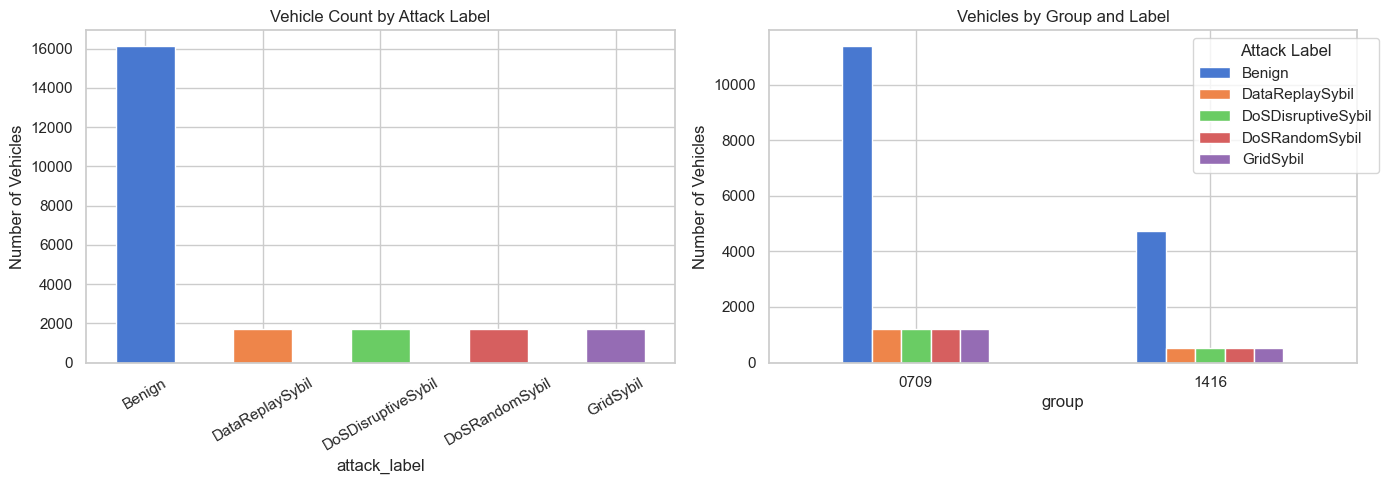

In [13]:
# 5.1 Vehicle count by attack family and group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By attack label
ax = axes[0]
df_vehicles['attack_label'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette())
ax.set_title('Vehicle Count by Attack Label')
ax.set_ylabel('Number of Vehicles')
ax.tick_params(axis='x', rotation=30)

# By group
ax = axes[1]
ct = df_vehicles.groupby(['group', 'attack_label']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax)
ax.set_title('Vehicles by Group and Label')
ax.set_ylabel('Number of Vehicles')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Attack Label', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('data/prepared_data/fig_vehicle_counts.png', dpi=150, bbox_inches='tight')
plt.show()

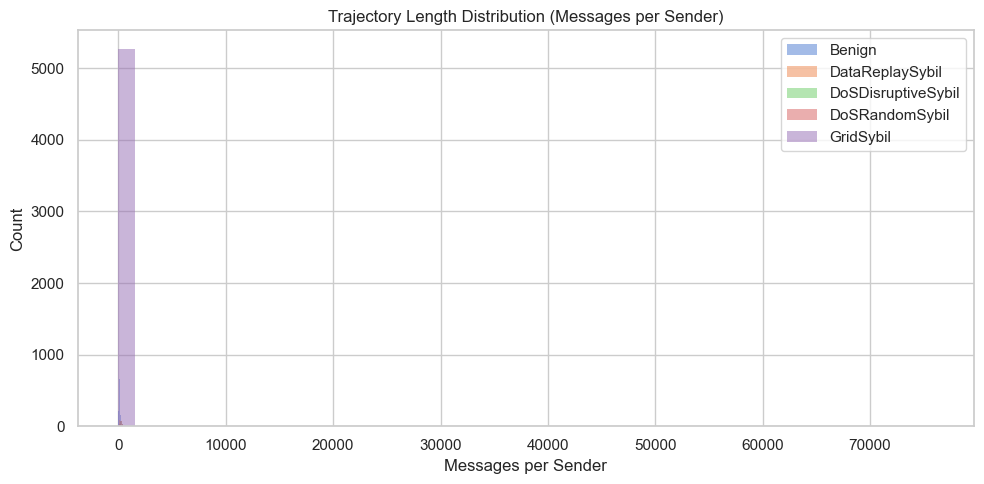

In [14]:
# 5.2 Message count distribution per sender by class
fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(msgs_per_sender['attack_label'].unique()):
    subset = msgs_per_sender[msgs_per_sender['attack_label'] == label]['msg_count']
    ax.hist(subset, bins=50, alpha=0.5, label=label, edgecolor='none')
ax.set_xlabel('Messages per Sender')
ax.set_ylabel('Count')
ax.set_title('Trajectory Length Distribution (Messages per Sender)')
ax.legend()
plt.tight_layout()
plt.savefig('data/prepared_data/fig_traj_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/db/lskr0w394ng50mbc22ygfkn00000gn/T/ipykernel_55255/1630910635.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df_gt.groupby('attack_label').apply(lambda x: x.sample(min(len(x), 50000), random_state=42)).reset_index(drop=True)


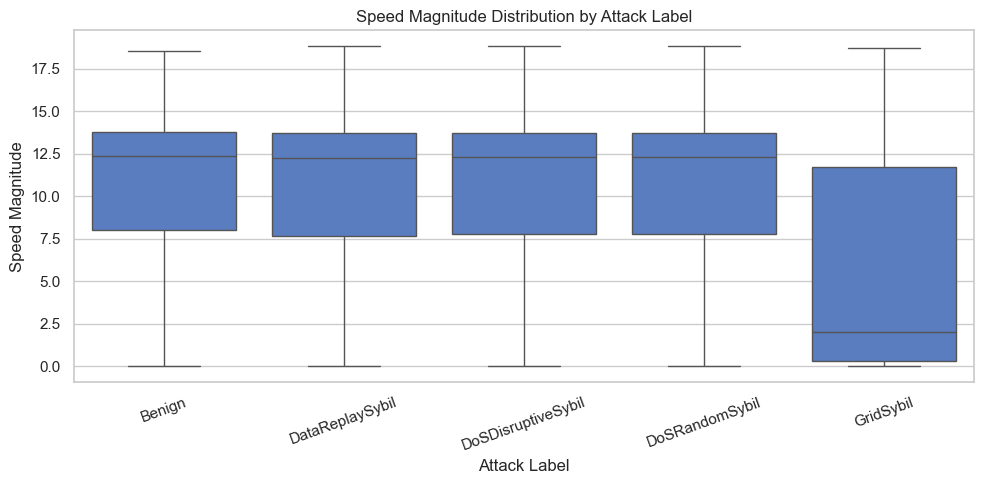

In [15]:
# 5.3 Speed distribution by attack label
fig, ax = plt.subplots(figsize=(10, 5))
sample = df_gt.groupby('attack_label').apply(lambda x: x.sample(min(len(x), 50000), random_state=42)).reset_index(drop=True)
sns.boxplot(data=sample, x='attack_label', y='speed_mag', ax=ax, showfliers=False)
ax.set_title('Speed Magnitude Distribution by Attack Label')
ax.set_ylabel('Speed Magnitude')
ax.set_xlabel('Attack Label')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('data/prepared_data/fig_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

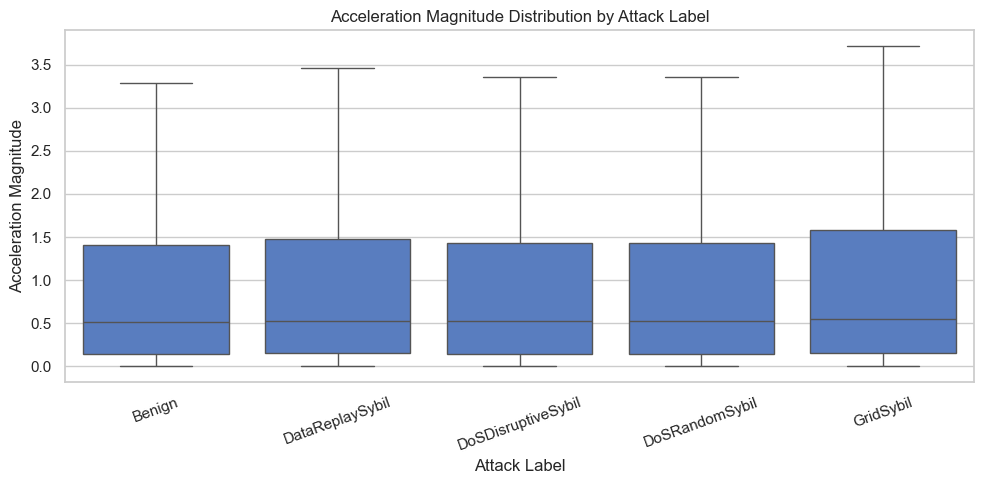

In [16]:
# 5.4 Acceleration distribution by attack label
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sample, x='attack_label', y='acl_mag', ax=ax, showfliers=False)
ax.set_title('Acceleration Magnitude Distribution by Attack Label')
ax.set_ylabel('Acceleration Magnitude')
ax.set_xlabel('Attack Label')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('data/prepared_data/fig_acl_dist.png', dpi=150, bbox_inches='tight')
plt.show()

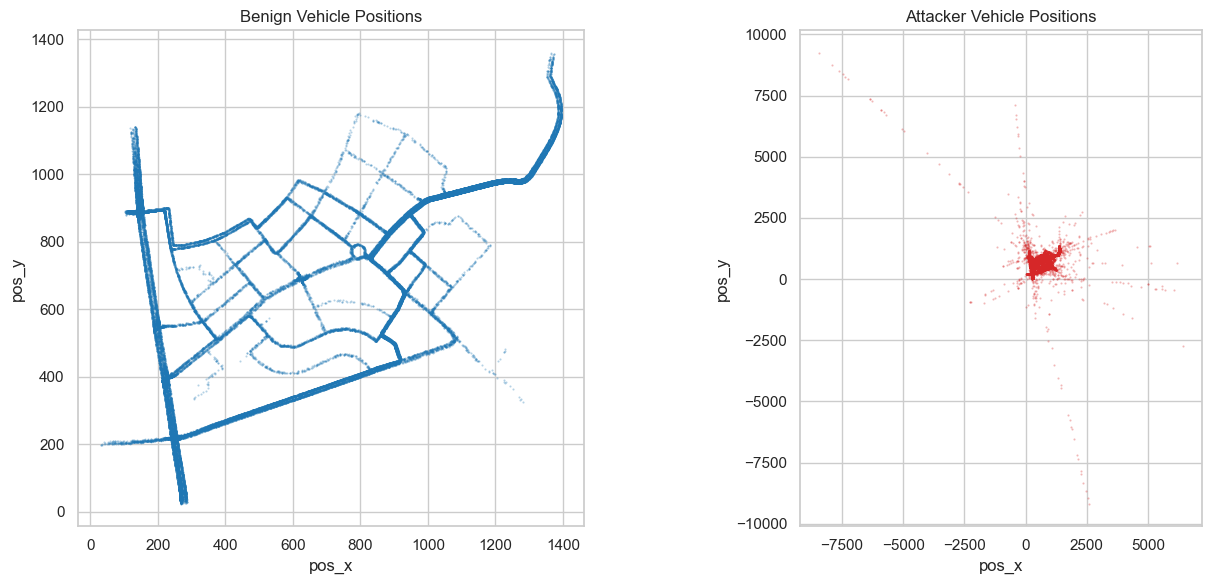

In [17]:
# 5.5 Spatial coverage — position scatter (sampled)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (label, color) in enumerate([("Benign", "tab:blue"), ("attacker", "tab:red")]):
    ax = axes[i]
    if label == "Benign":
        sub = df_gt[~df_gt['is_attacker']].sample(min(50000, (~df_gt['is_attacker']).sum()), random_state=42)
        ax.set_title('Benign Vehicle Positions')
    else:
        sub = df_gt[df_gt['is_attacker']].sample(min(50000, df_gt['is_attacker'].sum()), random_state=42)
        ax.set_title('Attacker Vehicle Positions')
    ax.scatter(sub['pos_x'], sub['pos_y'], s=0.3, alpha=0.3, c=color)
    ax.set_xlabel('pos_x')
    ax.set_ylabel('pos_y')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('data/prepared_data/fig_spatial_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

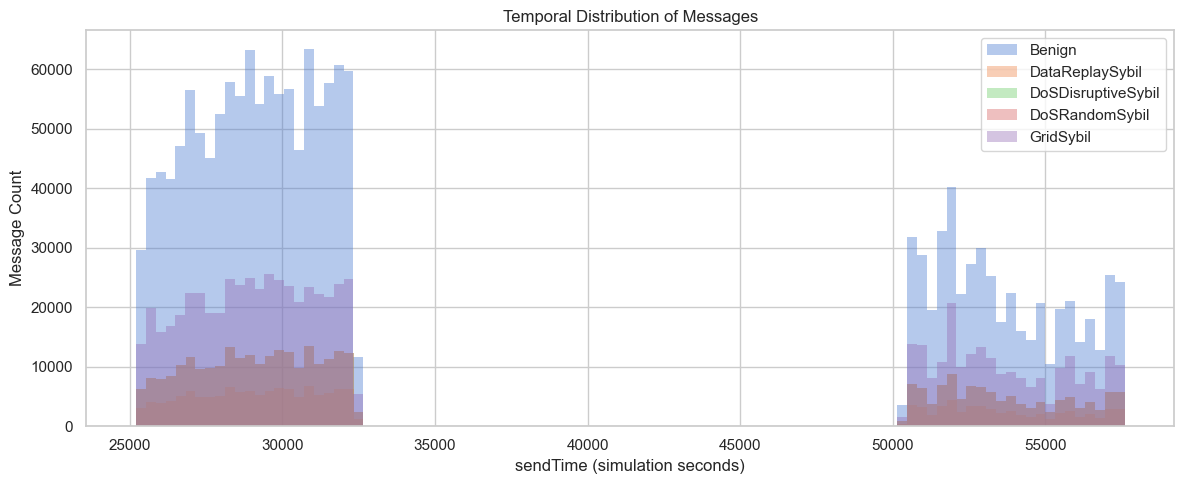

In [18]:
# 5.6 Temporal distribution of messages
fig, ax = plt.subplots(figsize=(12, 5))
for label in sorted(df_gt['attack_label'].unique()):
    sub = df_gt[df_gt['attack_label'] == label]
    ax.hist(sub['sendTime'], bins=100, alpha=0.4, label=label, edgecolor='none')
ax.set_xlabel('sendTime (simulation seconds)')
ax.set_ylabel('Message Count')
ax.set_title('Temporal Distribution of Messages')
ax.legend()
plt.tight_layout()
plt.savefig('data/prepared_data/fig_temporal_dist.png', dpi=150, bbox_inches='tight')
plt.show()

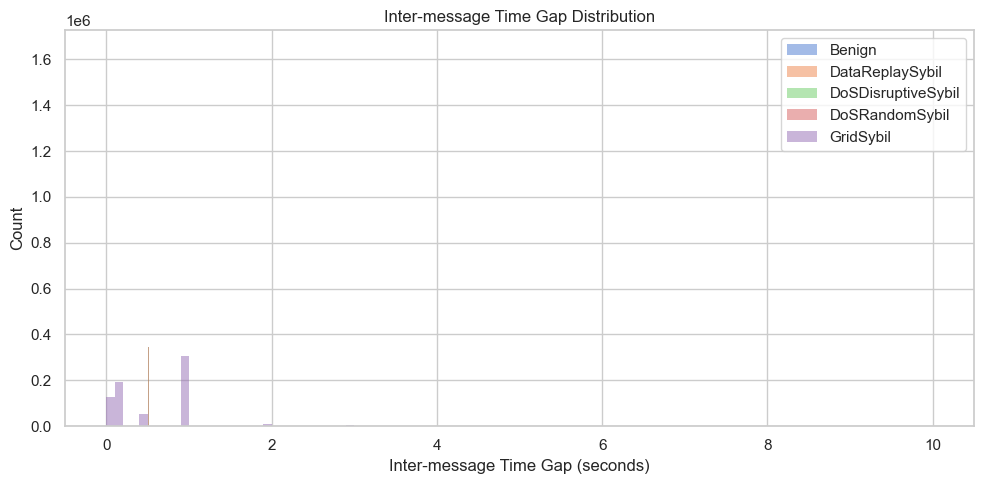


Time delta stats by class:


,count,mean,std,min,25%,50%,75%,max
attack_label,,,,,,,,
Benign,1644470.0,1.0000,0.0000,1.0,1.0000,1.0,1.0,1.0
DataReplaySybil,173217.0,1.0000,0.0000,1.0,1.0000,1.0,1.0,1.0
DoSDisruptiveSybil,347317.0,0.5000,0.0000,0.5,0.5000,0.5,0.5,0.5
DoSRandomSybil,347317.0,0.5000,0.0000,0.5,0.5000,0.5,0.5,0.5
GridSybil,698240.0,0.6127,0.6876,0.0,0.1667,0.5,1.0,10.0


In [19]:
# 5.7 Inter-message time gaps per sender
# Compute time deltas within each sender sequence
df_gt_sorted = df_gt.sort_values(['family', 'group', 'subfolder', 'senderPseudo', 'sendTime'])
df_gt_sorted['time_delta'] = df_gt_sorted.groupby(
    ['family', 'group', 'subfolder', 'senderPseudo']
)['sendTime'].diff()

fig, ax = plt.subplots(figsize=(10, 5))
valid_deltas = df_gt_sorted[df_gt_sorted['time_delta'].notna() & (df_gt_sorted['time_delta'] < 10)]
for label in sorted(valid_deltas['attack_label'].unique()):
    sub = valid_deltas[valid_deltas['attack_label'] == label]['time_delta']
    ax.hist(sub, bins=100, alpha=0.5, label=label, edgecolor='none')
ax.set_xlabel('Inter-message Time Gap (seconds)')
ax.set_ylabel('Count')
ax.set_title('Inter-message Time Gap Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('data/prepared_data/fig_time_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTime delta stats by class:")
valid_deltas.groupby('attack_label')['time_delta'].describe().round(4)

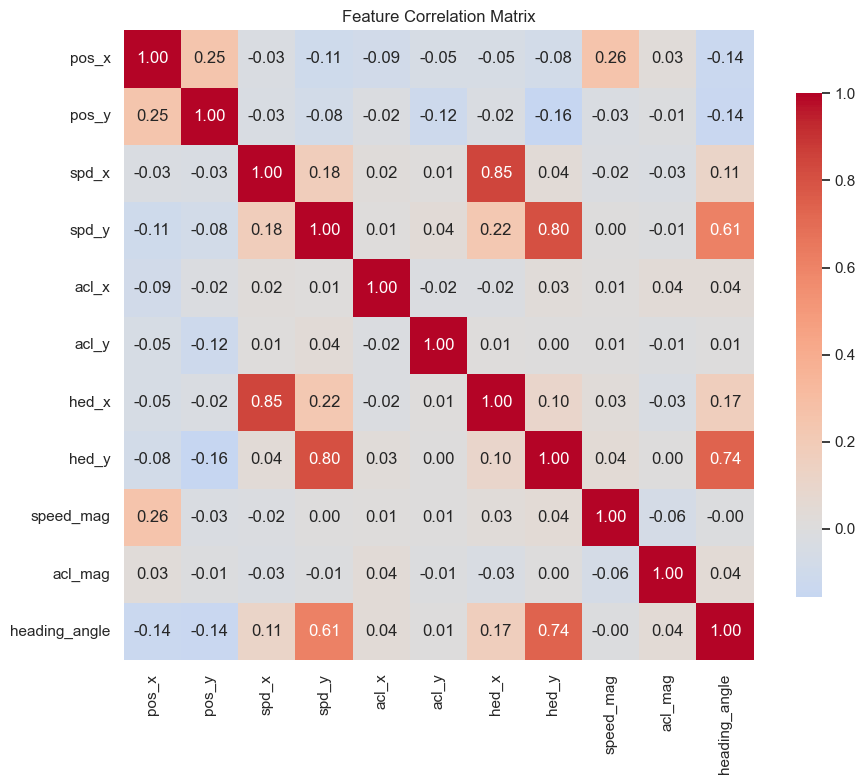

In [20]:
# 5.8 Feature correlation heatmap
feat_cols = ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'acl_x', 'acl_y',
             'hed_x', 'hed_y', 'speed_mag', 'acl_mag', 'heading_angle']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_gt[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('data/prepared_data/fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prepare Model-Ready Dataset

Build fixed-length trajectory windows from ground-truth messages, aligned by sender pseudonym.

**Pipeline:**
1. Sort messages by (family, group, subfolder, senderPseudo, sendTime)
2. Compute per-step delta features (Δtime, Δposition, Δvelocity)
3. Create fixed-length sliding windows (length T) per sender
4. Assign labels (benign vs attack family) per window
5. Leakage-safe split: partition at the sender level, then generate windows

In [21]:
WINDOW_SIZE = 20     # T: number of timesteps per window
STRIDE = 10          # sliding window stride (non-overlapping if stride == WINDOW_SIZE)
MIN_SEQ_LEN = 20    # minimum messages per sender to create at least 1 window

print(f"Window size: {WINDOW_SIZE}, Stride: {STRIDE}, Min sequence length: {MIN_SEQ_LEN}")

Window size: 20, Stride: 10, Min sequence length: 20


In [22]:
# Step 1: Sort and group by sender
df_sorted = df_gt.sort_values(['family', 'group', 'subfolder', 'senderPseudo', 'sendTime']).copy()

# Step 2: Compute delta features within each sender sequence
group_keys = ['family', 'group', 'subfolder', 'senderPseudo']
df_sorted['dt'] = df_sorted.groupby(group_keys)['sendTime'].diff().fillna(0.0)
df_sorted['dpos_x'] = df_sorted.groupby(group_keys)['pos_x'].diff().fillna(0.0)
df_sorted['dpos_y'] = df_sorted.groupby(group_keys)['pos_y'].diff().fillna(0.0)
df_sorted['dspd_x'] = df_sorted.groupby(group_keys)['spd_x'].diff().fillna(0.0)
df_sorted['dspd_y'] = df_sorted.groupby(group_keys)['spd_y'].diff().fillna(0.0)

# Feature columns for model input (matching proposal Section 3.2)
feature_cols = [
    'pos_x', 'pos_y',       # position
    'spd_x', 'spd_y',       # velocity
    'acl_x', 'acl_y',       # acceleration
    'hed_x', 'hed_y',       # heading
    'dt',                    # temporal delta
    'dpos_x', 'dpos_y',     # displacement delta
    'dspd_x', 'dspd_y',     # velocity delta
]

print(f"Feature vector dimension: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Feature vector dimension: 13
Features: ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'acl_x', 'acl_y', 'hed_x', 'hed_y', 'dt', 'dpos_x', 'dpos_y', 'dspd_x', 'dspd_y']


### Feature Vector Details (D=13 dimensions per timestep)

**Position Features (2D):**
- `pos_x`, `pos_y` — Absolute 2D position on road network (meters). Range: ±10km for attackers, confined for benign.

**Velocity Features (2D):**
- `spd_x`, `spd_y` — Velocity components (m/s). Benign mean: 10.2 m/s; GridSybil mean: 5.2 m/s.

**Acceleration Features (2D):**
- `acl_x`, `acl_y` — Acceleration components (m/s²). Mean ~1.0 m/s² across all classes.

**Heading Features (2D as unit vector):**
- `hed_x`, `hed_y` — Unit direction vector (normalized). Forms basis for heading angle.

**Temporal Delta:**
- `dt` — Time gap since last message (seconds). Benign: 1.0s; DoS attackers: 0.5s. **Strong discriminator.**

**Displacement Deltas (per-step changes):**
- `dpos_x`, `dpos_y` — Position change from previous timestep (meters). Captures local trajectory curvature.
- `dspd_x`, `dspd_y` — Velocity change (acceleration discretization for model input).

**Key Properties:**
- All position/velocity/acceleration values are 3D arrays `[x, y, 0.0]` in raw data — only first 2 used (2D road network)
- Features computed on training set only for normalization (μ, σ) stored in `norm_mean/std.npy`
- High correlations: spd ↔ hed (0.80-0.85) reflecting road-constrained kinematics
- No missing values (filled deltas with 0 at sequence boundaries)

In [23]:
# Step 3: Create fixed-length windows per sender
windows = []           # list of (T, D) numpy arrays
window_meta = []       # metadata for each window

sender_groups = df_sorted.groupby(group_keys)

for name, grp in tqdm(sender_groups, desc="Building windows"):
    family, group, subfolder, pseudo = name
    
    if len(grp) < MIN_SEQ_LEN:
        continue
    
    features = grp[feature_cols].values.astype(np.float32)
    attack_label = grp['attack_label'].iloc[0]
    attack_code = grp['attack_code'].iloc[0]
    attacker = grp['is_attacker'].iloc[0]
    
    n_steps = len(features)
    for start in range(0, n_steps - WINDOW_SIZE + 1, STRIDE):
        window = features[start:start + WINDOW_SIZE]
        assert window.shape == (WINDOW_SIZE, len(feature_cols))
        windows.append(window)
        window_meta.append({
            'family': family,
            'group': group,
            'subfolder': subfolder,
            'senderPseudo': pseudo,
            'attack_code': attack_code,
            'attack_label': attack_label,
            'is_attacker': attacker,
            'window_start_idx': start,
            'start_time': grp['sendTime'].iloc[start],
            'end_time': grp['sendTime'].iloc[start + WINDOW_SIZE - 1],
        })

X = np.stack(windows)  # (N, T, D)
df_meta = pd.DataFrame(window_meta)

print(f"\nTotal windows: {X.shape[0]:,}")
print(f"Window shape: {X.shape}  (N_windows, T={WINDOW_SIZE}, D={len(feature_cols)})")
print(f"\nWindows per attack label:")
print(df_meta['attack_label'].value_counts())
print(f"\nWindows per group:")
print(df_meta['group'].value_counts())

Building windows: 100%|██████████| 26567/26567 [00:05<00:00, 4569.59it/s]



Total windows: 285,926
Window shape: (285926, 20, 13)  (N_windows, T=20, D=13)

Windows per attack label:
attack_label
Benign                142925
GridSybil              63153
DoSDisruptiveSybil     32412
DoSRandomSybil         32412
DataReplaySybil        15024
Name: count, dtype: int64

Windows per group:
group
0709    195551
1416     90375
Name: count, dtype: int64


In [24]:
# Step 4: Leakage-safe train/val/test split at the sender level
from sklearn.model_selection import GroupShuffleSplit

# Create a unique sender ID for splitting
df_meta['sender_uid'] = (
    df_meta['family'] + '_' + df_meta['group'] + '_' + 
    df_meta['subfolder'] + '_' + df_meta['senderPseudo'].astype(str)
)

# First split: 80% train+val, 20% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, groups=df_meta['sender_uid']))

# Second split: 80% of remaining for train, 20% for val => 64% train, 16% val overall
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
rel_train_idx, rel_val_idx = next(gss2.split(
    X[train_val_idx], groups=df_meta.iloc[train_val_idx]['sender_uid']
))
train_idx = train_val_idx[rel_train_idx]
val_idx = train_val_idx[rel_val_idx]

# Verify no leakage
train_senders = set(df_meta.iloc[train_idx]['sender_uid'])
val_senders = set(df_meta.iloc[val_idx]['sender_uid'])
test_senders = set(df_meta.iloc[test_idx]['sender_uid'])

assert len(train_senders & val_senders) == 0, "Train-val leakage!"
assert len(train_senders & test_senders) == 0, "Train-test leakage!"
assert len(val_senders & test_senders) == 0, "Val-test leakage!"

print(f"Split sizes (windows):")
print(f"  Train: {len(train_idx):,} ({len(train_idx)/len(X):.1%})")
print(f"  Val:   {len(val_idx):,} ({len(val_idx)/len(X):.1%})")
print(f"  Test:  {len(test_idx):,} ({len(test_idx)/len(X):.1%})")
print(f"\nUnique senders:")
print(f"  Train: {len(train_senders):,}")
print(f"  Val:   {len(val_senders):,}")
print(f"  Test:  {len(test_senders):,}")
print(f"\nNo sender leakage across splits: ✓")

Split sizes (windows):
  Train: 188,647 (66.0%)
  Val:   43,491 (15.2%)
  Test:  53,788 (18.8%)

Unique senders:
  Train: 16,124
  Val:   4,031
  Test:  5,039

No sender leakage across splits: ✓


In [25]:
# Verify class balance across splits
for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    dist = df_meta.iloc[idx]['attack_label'].value_counts(normalize=True)
    print(f"\n{name} class distribution:")
    print(dist.round(3))


Train class distribution:
attack_label
Benign                0.485
GridSybil             0.246
DoSRandomSybil        0.109
DoSDisruptiveSybil    0.108
DataReplaySybil       0.052
Name: proportion, dtype: float64

Val class distribution:
attack_label
Benign                0.526
GridSybil             0.178
DoSDisruptiveSybil    0.124
DoSRandomSybil        0.119
DataReplaySybil       0.053
Name: proportion, dtype: float64

Test class distribution:
attack_label
Benign                0.530
GridSybil             0.168
DoSDisruptiveSybil    0.124
DoSRandomSybil        0.122
DataReplaySybil       0.056
Name: proportion, dtype: float64


In [26]:
# Step 5: Also prepare scenario-holdout splits (0709 vs 1416) for evaluation
group_0709_mask = df_meta['group'] == '0709'
group_1416_mask = df_meta['group'] == '1416'

idx_0709 = np.where(group_0709_mask.values)[0]
idx_1416 = np.where(group_1416_mask.values)[0]

print(f"Scenario-holdout split:")
print(f"  Group 0709: {len(idx_0709):,} windows")
print(f"  Group 1416: {len(idx_1416):,} windows")
print(f"\nGroup 0709 class distribution:")
print(df_meta.iloc[idx_0709]['attack_label'].value_counts())
print(f"\nGroup 1416 class distribution:")
print(df_meta.iloc[idx_1416]['attack_label'].value_counts())

Scenario-holdout split:
  Group 0709: 195,551 windows
  Group 1416: 90,375 windows

Group 0709 class distribution:
attack_label
Benign                99873
GridSybil             41277
DoSDisruptiveSybil    22094
DoSRandomSybil        22094
DataReplaySybil       10213
Name: count, dtype: int64

Group 1416 class distribution:
attack_label
Benign                43052
GridSybil             21876
DoSDisruptiveSybil    10318
DoSRandomSybil        10318
DataReplaySybil        4811
Name: count, dtype: int64


In [27]:
# Step 6: Compute normalization statistics from training set only
X_train = X[train_idx]
# Flatten to (N_train * T, D) for per-feature stats
X_train_flat = X_train.reshape(-1, X_train.shape[-1])

feat_mean = X_train_flat.mean(axis=0)
feat_std = X_train_flat.std(axis=0)
feat_std[feat_std < 1e-8] = 1.0  # avoid division by zero for constant features

norm_stats = pd.DataFrame({
    'feature': feature_cols,
    'mean': feat_mean,
    'std': feat_std,
})
print("Normalization statistics (computed on training set only):")
norm_stats

Normalization statistics (computed on training set only):


,feature,mean,std
0,pos_x,591.132629,421.403137
1,pos_y,669.416382,334.986237
2,spd_x,-0.451034,7.621582
3,spd_y,-0.033699,7.460384
4,acl_x,0.005306,0.972309
5,acl_y,0.003988,1.107263
6,hed_x,-0.071930,0.698269
7,hed_y,0.014217,0.710589
8,dt,0.782918,0.773564
9,dpos_x,-0.314849,253.198624


In [28]:
# Step 7: Encode labels
label_to_int = {label: i for i, label in enumerate(sorted(df_meta['attack_label'].unique()))}
int_to_label = {v: k for k, v in label_to_int.items()}

y = df_meta['attack_label'].map(label_to_int).values.astype(np.int64)
y_binary = df_meta['is_attacker'].astype(np.int64).values  # 0=benign, 1=attacker

print("Label encoding:")
for k, v in sorted(label_to_int.items()):
    count = (y == v).sum()
    print(f"  {v}: {k} ({count:,} windows)")
print(f"\nBinary: 0=Benign ({(y_binary == 0).sum():,}), 1=Attacker ({(y_binary == 1).sum():,})")

Label encoding:
  0: Benign (142,925 windows)
  1: DataReplaySybil (15,024 windows)
  2: DoSDisruptiveSybil (32,412 windows)
  3: DoSRandomSybil (32,412 windows)
  4: GridSybil (63,153 windows)

Binary: 0=Benign (142,925), 1=Attacker (143,001)


## 7. Save Prepared Data

In [29]:
# Save all artifacts to data/prepared_data/
import json as json_mod

# Windows array: (N, T, D)
np.save(PREPARED / 'X_windows.npy', X)

# Labels
np.save(PREPARED / 'y_multiclass.npy', y)
np.save(PREPARED / 'y_binary.npy', y_binary)

# Split indices
np.save(PREPARED / 'idx_train.npy', train_idx)
np.save(PREPARED / 'idx_val.npy', val_idx)
np.save(PREPARED / 'idx_test.npy', test_idx)

# Scenario-holdout indices
np.save(PREPARED / 'idx_group_0709.npy', idx_0709)
np.save(PREPARED / 'idx_group_1416.npy', idx_1416)

# Normalization statistics
np.save(PREPARED / 'norm_mean.npy', feat_mean)
np.save(PREPARED / 'norm_std.npy', feat_std)

# Metadata
df_meta.to_parquet(PREPARED / 'window_metadata.parquet', index=False)

# Config/manifest
config = {
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'min_seq_len': MIN_SEQ_LEN,
    'feature_cols': feature_cols,
    'feature_dim': len(feature_cols),
    'n_windows': int(X.shape[0]),
    'n_train': int(len(train_idx)),
    'n_val': int(len(val_idx)),
    'n_test': int(len(test_idx)),
    'n_group_0709': int(len(idx_0709)),
    'n_group_1416': int(len(idx_1416)),
    'label_to_int': label_to_int,
    'int_to_label': {str(k): v for k, v in int_to_label.items()},
    'norm_mean': feat_mean.tolist(),
    'norm_std': feat_std.tolist(),
}
with open(PREPARED / 'config.json', 'w') as f:
    json_mod.dump(config, f, indent=2)

print("Saved to data/prepared_data/:")
for f in sorted(PREPARED.glob('*')):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:35s} {size_mb:8.2f} MB")

Saved to data/prepared_data/:
  X_windows.npy                         297.36 MB
  config.json                             0.00 MB
  fig_acl_dist.png                        0.06 MB
  fig_correlation.png                     0.18 MB
  fig_spatial_coverage.png                0.18 MB
  fig_speed_dist.png                      0.05 MB
  fig_temporal_dist.png                   0.06 MB
  fig_time_gaps.png                       0.05 MB
  fig_traj_length_dist.png                0.05 MB
  fig_vehicle_counts.png                  0.10 MB
  idx_group_0709.npy                      1.56 MB
  idx_group_1416.npy                      0.72 MB
  idx_test.npy                            0.43 MB
  idx_train.npy                           1.51 MB
  idx_val.npy                             0.35 MB
  norm_mean.npy                           0.00 MB
  norm_std.npy                            0.00 MB
  window_metadata.parquet                 4.48 MB
  y_binary.npy                            2.29 MB
  y_multiclass.npy  

### Dataset Statistics & Key Findings

**Scale:**
- Total vehicles (trace files): 23,032
- Total ground truth messages: 3,240,283
- Unique sender sequences: 26,567
- Total trajectory windows generated: 285,926 (T=20, D=13)

**Class Distribution (by windows):**
| Class | Count | % |
|---|---|---|
| Benign | 142,925 | 50.0% |
| GridSybil | 63,153 | 22.1% |
| DoSDisruptiveSybil | 32,412 | 11.3% |
| DoSRandomSybil | 32,412 | 11.3% |
| DataReplaySybil | 15,024 | 5.3% |
| **Total** | **285,926** | **100%** |

**Split Information:**
- Train: 188,647 windows (66%) from 16,124 senders
- Val: 43,491 windows (15%) from 4,031 senders  
- Test: 53,788 windows (19%) from 5,039 senders
- **Leakage-safe**: No sender appears in multiple splits

**Scenario Groups:**
- 0709 (morning): 195,551 windows (68%)
- 1416 (afternoon): 90,375 windows (32%)

**Trajectory Lengths:**
- Benign: 103 messages/sender (mean), range 1-312
- DoS attacks: 202 messages/sender (mean)
- GridSybil: 134 messages/sender (mean), outliers up to 75,905 (grid-sweep vehicle)

**Key EDA Discoveries:**
1. Benign vehicles trace clear/distinct road patterns; attackers scatter off-road
2. DoS attacks send at **2× normal rate** (0.5s vs 1.0s intervals) — highly discriminative temporal signal
3. Speed differs significantly: Benign ~10.2 m/s, GridSybil ~5.2 m/s (harder to move off-road)
4. Kinematic features show high correlation (0.80-0.85 between velocity and heading), confirming road-constrained simulation
5. All 5 classes are reasonably represented; nearly balanced benign/attacker split by windows (50%/50%)

In [30]:
# Quick verification: reload and check
X_check = np.load(PREPARED / 'X_windows.npy')
y_check = np.load(PREPARED / 'y_multiclass.npy')
idx_train_check = np.load(PREPARED / 'idx_train.npy')
with open(PREPARED / 'config.json') as f:
    cfg = json_mod.load(f)

print("=== Verification ===")
print(f"X shape: {X_check.shape}")
print(f"y shape: {y_check.shape}")
print(f"Train indices: {len(idx_train_check):,}")
print(f"Feature dim: {cfg['feature_dim']}")
print(f"Features: {cfg['feature_cols']}")
print(f"Labels: {cfg['label_to_int']}")
print(f"\nArrays match: {np.array_equal(X_check, X) and np.array_equal(y_check, y)}")

=== Verification ===
X shape: (285926, 20, 13)
y shape: (285926,)
Train indices: 188,647
Feature dim: 13
Features: ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'acl_x', 'acl_y', 'hed_x', 'hed_y', 'dt', 'dpos_x', 'dpos_y', 'dspd_x', 'dspd_y']
Labels: {'Benign': 0, 'DataReplaySybil': 1, 'DoSDisruptiveSybil': 2, 'DoSRandomSybil': 3, 'GridSybil': 4}

Arrays match: True


## 8. Summary

### Dataset Overview
- **Source:** VeReMi Sybil Attack Benchmark (SUMO-generated, road-network-grounded)
- **Attack families:** DataReplaySybil (A17), DoSRandomSybil (A18), DoSDisruptiveSybil (A19), GridSybil (A16)
- **Groups:** `0709` (7am-9am scenarios), `1416` (2pm-4pm scenarios)
- **Labels derived from:** Trace filenames (`A0` = benign, `A{code}` = attack type)

### Prepared Data (`data/prepared_data/`)
- `X_windows.npy` — Feature windows, shape (N, T=20, D=13)
- `y_multiclass.npy` — Multi-class labels (5 classes: Benign + 4 attack families)
- `y_binary.npy` — Binary labels (0=Benign, 1=Attacker)
- `idx_train/val/test.npy` — Leakage-safe sender-level split indices
- `idx_group_0709/1416.npy` — Scenario-holdout split indices
- `norm_mean/std.npy` — Per-feature normalization stats (from train set only)
- `window_metadata.parquet` — Full metadata per window
- `config.json` — Pipeline configuration, label mappings, feature names

### Data Preparation Methodology

**Window Creation Pipeline:**
1. **Sort by sender**: Messages grouped and sorted by (family, group, subfolder, senderPseudo, sendTime)
2. **Compute deltas**: Per-sender, compute dt, dpos, dspd to capture temporal dynamics
3. **Sliding windows**: Extract T=20 timestep windows with stride=10 from sequences ≥20 messages
4. **Label assignment**: Each window inherits label from sender (uniform within sender)
5. **Leakage prevention**: Split at sender level BEFORE windowing → no sender appears twice

**Normalization:**
- Mean/std computed on training set only (computed from X_train flattened to shape [N_train×T, D])
- Prevents data leakage from val/test statistics
- Stored in `norm_mean.npy` and `norm_std.npy` for reproducible preprocessing

**Train/Val/Test Strategy:**
- 80/20 split (train+val vs test) using GroupShuffleSplit by sender_uid
- Then 80/20 of train+val split (train vs val)
- Result: 64% train, 16% val, 20% test overall
- Ensures each sender appears in exactly ONE split

**Scenario-Holdout Splits:**
- `idx_group_0709`: 195,551 windows (all morning scenarios)
- `idx_group_1416`: 90,375 windows (all afternoon scenarios)
- Useful for evaluating cross-scenario generalization (train on 0709, test on 1416)